# Tiền xử lý NSL-KDD — Phiên bản chuẩn cho QSVM-IDS

Pipeline tiền xử lý giữ nguyên **3 lớp nhãn** để phục vụ toàn bộ khung nghiên cứu:

| Cột | Ý nghĩa | Dùng cho |
|-----|---------|----------|
| `label_binary` | 0 = Normal, 1 = Attack | Train/eval QSVM (C1–C3) |
| `label_multiclass` | neptune, smurf, ... (22 loại) | Phân tích chi tiết (C4) |
| `attack_category` | Normal / DoS / Probe / R2L / U2R | Stratified sampling đúng cách |

## 0. Import & kiểm tra phiên bản

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
import random

warnings.filterwarnings('ignore')

# --- THIẾT LẬP GLOBAL SEED ĐỂ ĐẢM BẢO REPRODUCIBLE ---
SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)
# -----------------------------------------------------

from sklearn.preprocessing import MinMaxScaler

print(f"Pandas    : {pd.__version__}")
print(f"NumPy     : {np.__version__}")
print(f"Scikit    : {__import__('sklearn').__version__}")

Pandas    : 2.3.3
NumPy     : 2.2.6
Scikit    : 1.7.2


## 1. Cấu hình — chỉnh đường dẫn tại đây

In [2]:
# ── Đường dẫn dữ liệu gốc ──
TRAIN_PATH = '../data/raw/KDDTrain+.txt'
TEST_PATH  = '../data/raw/KDDTest+.txt'

# ── Thư mục lưu output ──
OUTPUT_DIR = '../data/processed_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Map attack type → category (dùng chung cho train và test) ──
# Nguồn: KDD Cup 1999 task description + NSL-KDD paper
ATTACK_CATEGORY_MAP = {
    # Normal
    'normal'          : 'Normal',
    # DoS — Denial of Service
    'neptune'         : 'DoS',  'smurf'       : 'DoS',
    'pod'             : 'DoS',  'teardrop'    : 'DoS',
    'back'            : 'DoS',  'land'        : 'DoS',
    'mailbomb'        : 'DoS',  'apache2'     : 'DoS',
    'processtable'    : 'DoS',  'udpstorm'    : 'DoS',
    'worm'            : 'DoS',
    # Probe — Surveillance / Scanning
    'ipsweep'         : 'Probe', 'portsweep'  : 'Probe',
    'nmap'            : 'Probe', 'satan'       : 'Probe',
    'mscan'           : 'Probe', 'saint'       : 'Probe',
    # R2L — Remote to Local
    'ftp_write'       : 'R2L',  'guess_passwd': 'R2L',
    'imap'            : 'R2L',  'multihop'    : 'R2L',
    'phf'             : 'R2L',  'spy'         : 'R2L',
    'warezclient'     : 'R2L',  'warezmaster' : 'R2L',
    'sendmail'        : 'R2L',  'named'       : 'R2L',
    'snmpgetattack'   : 'R2L',  'xlock'       : 'R2L',
    'xsnoop'          : 'R2L',  'httptunnel'  : 'R2L',
    'snmpguess'       : 'R2L',
    # U2R — User to Root
    'buffer_overflow' : 'U2R',  'loadmodule'  : 'U2R',
    'perl'            : 'U2R',  'rootkit'     : 'U2R',
    'sqlattack'       : 'U2R',  'xterm'       : 'U2R',
    'ps'              : 'U2R',
}

# ── 43 cột gốc của NSL-KDD ──
COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

CATEGORICAL_COLS = ['protocol_type', 'service', 'flag']
LABEL_COLS       = ['label_binary', 'label_multiclass', 'attack_category']
EXCLUDED_COLS     = ['label']

print("Cấu hình OK")
print(f"  Train path : {TRAIN_PATH}")
print(f"  Test path  : {TEST_PATH}")
print(f"  Output dir : {OUTPUT_DIR}")

Cấu hình OK
  Train path : ../data/raw/KDDTrain+.txt
  Test path  : ../data/raw/KDDTest+.txt
  Output dir : ../data/processed_data


## 2. Hàm tiền xử lý

In [3]:
def add_label_columns(df, split_name=''):
    """
    Tạo 3 cột nhãn từ cột 'label' gốc.
    Cảnh báo nếu có attack type chưa có trong ATTACK_CATEGORY_MAP.
    """
    df['label_binary']     = (df['label'] != 'normal').astype(int)
    df['label_multiclass'] = df['label'].copy()
    df['attack_category']  = df['label'].map(ATTACK_CATEGORY_MAP)

    unknown = df[df['attack_category'].isna()]['label'].unique()
    if len(unknown) > 0:
        print(f"  ⚠  [{split_name}] {len(unknown)} attack type chưa có trong map → gán 'Unknown'")
        print(f"     Cần thêm vào ATTACK_CATEGORY_MAP: {sorted(unknown)}")
        df['attack_category'] = df['attack_category'].fillna('Unknown')

    return df


def preprocess_nsl_kdd(train_path, test_path):
    """
    Tiền xử lý NSL-KDD: load → gán nhãn → one-hot → MinMaxScale.

    Returns
    -------
    train_proc : DataFrame  — features + 4 cột nhãn
    test_proc  : DataFrame  — features + 4 cột nhãn
    scaler     : MinMaxScaler đã fit trên train (dùng lại cho dataset mới)
    """
    # ── 1. Load ──
    print("[1/5] Đang load dữ liệu...")
    train_df = pd.read_csv(train_path, names=COLUMNS, header=None)
    test_df  = pd.read_csv(test_path,  names=COLUMNS, header=None)
    train_df.drop('difficulty_level', axis=1, inplace=True)
    test_df.drop('difficulty_level',  axis=1, inplace=True)
    print(f"   Train raw : {train_df.shape} | Test raw : {test_df.shape}")

    # ── 2. Gán nhãn (TRƯỚC mọi thao tác khác) ──
    print("[2/5] Tạo cột nhãn...")
    train_df = add_label_columns(train_df, 'Train')
    test_df  = add_label_columns(test_df,  'Test')

    # ── 3. Tách features và nhãn để tránh rò rỉ ──
    # QUAN TRỌNG: phải tách TRƯỚC get_dummies và MinMaxScaler
    # Nếu không, 'label' (string) sẽ bị one-hot encode thành feature,
    # và label_binary sẽ bị scale — cả hai đều sai.
    print("[3/5] One-Hot Encoding cho categorical features...")
    feature_cols = [c for c in train_df.columns if c not in LABEL_COLS]
    # Sau mỗi bước transformation, in shape để dễ debug:
    train_feat = train_df[feature_cols].copy()
    test_feat  = test_df[feature_cols].copy()
    train_lbl  = train_df[LABEL_COLS].reset_index(drop=True)
    test_lbl   = test_df[LABEL_COLS].reset_index(drop=True)

    X_train_enc = pd.get_dummies(train_feat, columns=CATEGORICAL_COLS, dtype=float)
    X_test_enc  = pd.get_dummies(test_feat,  columns=CATEGORICAL_COLS, dtype=float)

    # Test chỉ được phép có đúng các cột train đã thấy
    # - Category train có, test không có → test được fill 0 (đúng)
    # - Category test có, train không có → bị drop hoàn toàn (đúng)
    X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0.0)
    
    print(f"   Post-OHE — train: {X_train_enc.shape} | test: {X_test_enc.shape}")

    print(f"   Features sau one-hot : {X_train_enc.shape[1]} cột")
    
    train_feat_enc = X_train_enc
    test_feat_enc  = X_test_enc

    # ── 4. MinMaxScaler — chỉ trên numeric feature columns ──
    print("[4/5] Chuẩn hóa MinMax...")
    numeric_cols = train_feat_enc.select_dtypes(include=[np.number]).columns.tolist()
    scaler = MinMaxScaler()
    train_feat_enc[numeric_cols] = scaler.fit_transform(train_feat_enc[numeric_cols])
    
    # np.clip sau khi đã có scaler và numeric_cols
    test_feat_enc[numeric_cols] = np.clip(
        scaler.transform(test_feat_enc[numeric_cols]), 0, 1
    )

    # ── 5. Ghép features + nhãn ──
    print("[5/5] Ghép features và nhãn...")
    train_proc = pd.concat([train_feat_enc, train_lbl], axis=1)
    test_proc  = pd.concat([test_feat_enc,  test_lbl],  axis=1)

    return train_proc, test_proc, scaler


print("Hàm preprocess_nsl_kdd đã sẵn sàng")

Hàm preprocess_nsl_kdd đã sẵn sàng


## 3. Chạy tiền xử lý

In [4]:
train_clean, test_clean, scaler = preprocess_nsl_kdd(TRAIN_PATH, TEST_PATH)

# Kiểm tra nhanh cấu trúc output
feature_cols_out = [c for c in train_clean.columns if c not in LABEL_COLS and c not in EXCLUDED_COLS]

print("\n=== THÔNG TIN SAU XỬ LÝ ===")
print(f"  Train shape      : {train_clean.shape}")
print(f"  Test  shape      : {test_clean.shape}")
print(f"  Số features      : {len(feature_cols_out)}")
print(f"  Cột nhãn         : {LABEL_COLS}")
print(f"  Feature range    : [{train_clean[feature_cols_out].min().min():.3f}, "
      f"{train_clean[feature_cols_out].max().max():.3f}] (kỳ vọng [0, 1])")
print(f"  label_binary OK  : {set(train_clean['label_binary'].unique()) == {0, 1}}")
print(f"  NaN trong train  : {train_clean.isna().sum().sum()}")
print(f"  NaN trong test   : {test_clean.isna().sum().sum()}")
train_clean.head(3)

[1/5] Đang load dữ liệu...
   Train raw : (125973, 42) | Test raw : (22544, 42)
[2/5] Tạo cột nhãn...
[3/5] One-Hot Encoding cho categorical features...
   Post-OHE — train: (125973, 123) | test: (22544, 123)
   Features sau one-hot : 123 cột
[4/5] Chuẩn hóa MinMax...
[5/5] Ghép features và nhãn...

=== THÔNG TIN SAU XỬ LÝ ===
  Train shape      : (125973, 126)
  Test  shape      : (22544, 126)
  Số features      : 122
  Cột nhãn         : ['label_binary', 'label_multiclass', 'attack_category']
  Feature range    : [0.000, 1.000] (kỳ vọng [0, 1])
  label_binary OK  : True
  NaN trong train  : 0
  NaN trong test   : 0


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,label_binary,label_multiclass,attack_category
0,0.0,3.558064e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,normal,Normal
1,0.0,1.057999e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,normal,Normal
2,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1,neptune,DoS


## 4. Phân tích phân bố nhãn

In [5]:
# ── Bảng phân bố đầy đủ ──
def label_distribution_report(df, split_name):
    total = len(df)
    cat   = df['attack_category'].value_counts()
    multi = df['label_multiclass'].value_counts()

    print(f"\n{'='*55}")
    print(f"  {split_name} — {total:,} mẫu")
    print(f"{'='*55}")
    print(f"  {'Category':<12} {'Count':>8}  {'%':>6}")
    print(f"  {'-'*30}")
    for cat_name, cnt in cat.items():
        print(f"  {cat_name:<12} {cnt:>8,}  {cnt/total*100:>5.1f}%")
    print(f"  {'-'*30}")
    print(f"  {'TOTAL':<12} {total:>8,}  100.0%")

    print(f"\n  Attack types ({len(multi)} loại):")
    for name, cnt in multi.items():
        bar = '█' * min(30, int(cnt / total * 300))
        print(f"  {name:<20} {cnt:>6,}  {bar}")

label_distribution_report(train_clean, 'TRAIN')
label_distribution_report(test_clean,  'TEST')


  TRAIN — 125,973 mẫu
  Category        Count       %
  ------------------------------
  Normal         67,343   53.5%
  DoS            45,927   36.5%
  Probe          11,656    9.3%
  R2L               995    0.8%
  U2R                52    0.0%
  ------------------------------
  TOTAL         125,973  100.0%

  Attack types (23 loại):
  normal               67,343  ██████████████████████████████
  neptune              41,214  ██████████████████████████████
  satan                 3,633  ████████
  ipsweep               3,599  ████████
  portsweep             2,931  ██████
  smurf                 2,646  ██████
  nmap                  1,493  ███
  back                    956  ██
  teardrop                892  ██
  warezclient             890  ██
  pod                     201  
  guess_passwd             53  
  buffer_overflow          30  
  warezmaster              20  
  land                     18  
  imap                     11  
  rootkit                  10  
  loadmodule       

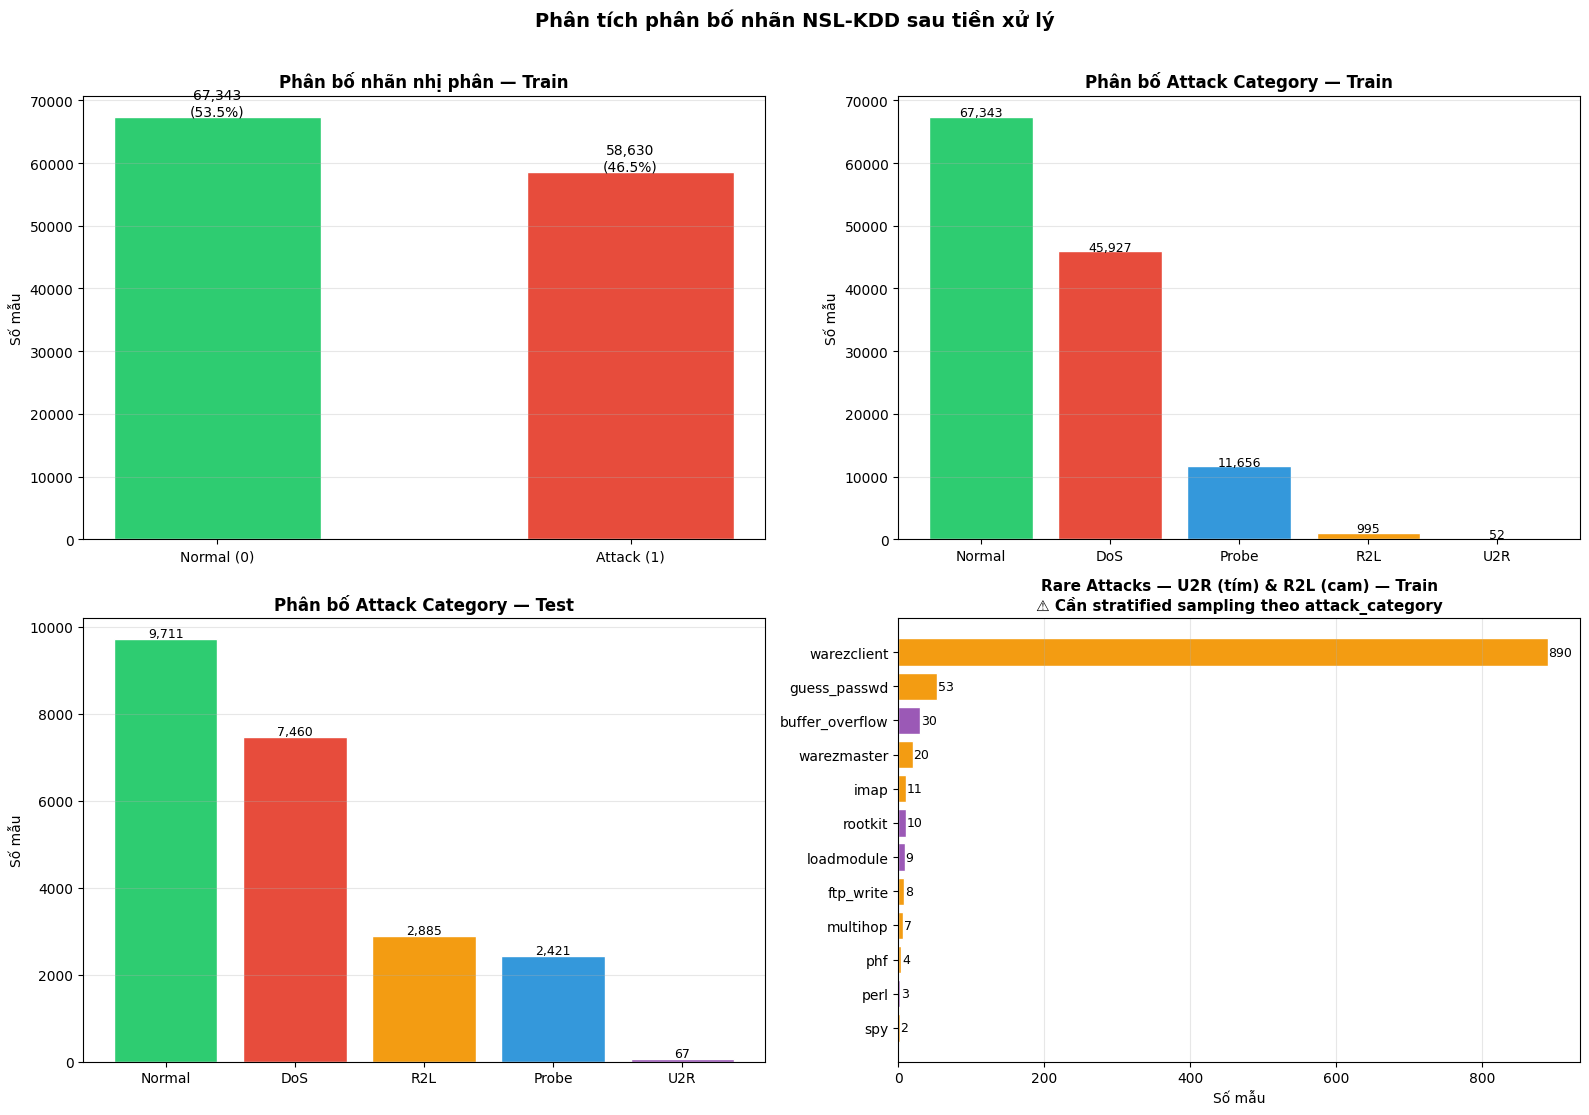

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

CATEGORY_COLORS = {
    'Normal': '#2ECC71', 'DoS': '#E74C3C',
    'Probe': '#3498DB',  'R2L': '#F39C12', 'U2R': '#9B59B6'
}

# ── Plot 1: Binary label — Train ──
binary_counts = train_clean['label_binary'].value_counts().sort_index()
axes[0,0].bar(['Normal (0)', 'Attack (1)'], binary_counts.values,
              color=['#2ECC71', '#E74C3C'], edgecolor='white', width=0.5)
for i, v in enumerate(binary_counts.values):
    axes[0,0].text(i, v + 200, f'{v:,}\n({v/len(train_clean)*100:.1f}%)',
                   ha='center', fontsize=10)
axes[0,0].set_title('Phân bố nhãn nhị phân — Train', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Số mẫu')
axes[0,0].grid(axis='y', alpha=0.3)

# ── Plot 2: Attack category — Train ──
cat_counts = train_clean['attack_category'].value_counts()
colors_cat = [CATEGORY_COLORS.get(c, '#95A5A6') for c in cat_counts.index]
axes[0,1].bar(cat_counts.index, cat_counts.values, color=colors_cat, edgecolor='white')
for i, v in enumerate(cat_counts.values):
    axes[0,1].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
axes[0,1].set_title('Phân bố Attack Category — Train', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Số mẫu')
axes[0,1].grid(axis='y', alpha=0.3)

# ── Plot 3: Attack category — Test ──
cat_counts_t = test_clean['attack_category'].value_counts()
colors_cat_t = [CATEGORY_COLORS.get(c, '#95A5A6') for c in cat_counts_t.index]
axes[1,0].bar(cat_counts_t.index, cat_counts_t.values, color=colors_cat_t, edgecolor='white')
for i, v in enumerate(cat_counts_t.values):
    axes[1,0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
axes[1,0].set_title('Phân bố Attack Category — Test', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Số mẫu')
axes[1,0].grid(axis='y', alpha=0.3)

# ── Plot 4: Rare attacks (U2R + R2L) zoom-in ──
rare_train = train_clean[train_clean['attack_category'].isin(['U2R', 'R2L'])]
rare_counts = rare_train['label_multiclass'].value_counts()
colors_rare = ['#9B59B6' if train_clean[train_clean['label_multiclass']==a]['attack_category'].iloc[0] == 'U2R'
               else '#F39C12' for a in rare_counts.index]
axes[1,1].barh(rare_counts.index, rare_counts.values, color=colors_rare, edgecolor='white')
for i, v in enumerate(rare_counts.values):
    axes[1,1].text(v + 1, i, str(v), va='center', fontsize=9)
axes[1,1].set_title('Rare Attacks — U2R (tím) & R2L (cam) — Train\n'
                     '⚠ Cần stratified sampling theo attack_category', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Số mẫu')
axes[1,1].grid(axis='x', alpha=0.3)
axes[1,1].invert_yaxis()

plt.suptitle('Phân tích phân bố nhãn NSL-KDD sau tiền xử lý',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Kiểm tra attack types chỉ có trong Train hoặc chỉ có trong Test

Quan trọng: các attack type chỉ có trong Test sẽ không bao giờ được học —  
cần ghi rõ trong phần Limitations của paper.

In [7]:
train_types = set(train_clean['label_multiclass'].unique())
test_types  = set(test_clean['label_multiclass'].unique())

only_in_train = sorted(train_types - test_types)
only_in_test  = sorted(test_types  - train_types)
in_both       = sorted(train_types & test_types)

print(f"Attack types trong cả Train và Test ({len(in_both)}):")
print(f"  {in_both}")

print(f"\nChỉ trong Train ({len(only_in_train)}) — mô hình học được nhưng không có trong test:")
print(f"  {only_in_train}")

print(f"\nChỉ trong Test ({len(only_in_test)}) — zero-shot, mô hình chưa thấy bao giờ:")
print(f"  {only_in_test}")
print(f"  → Đây là nguyên nhân chính khiến test accuracy thường thấp hơn train")
print(f"  → Cần ghi rõ trong phần Experimental Setup của paper")

Attack types trong cả Train và Test (21):
  ['back', 'buffer_overflow', 'ftp_write', 'guess_passwd', 'imap', 'ipsweep', 'land', 'loadmodule', 'multihop', 'neptune', 'nmap', 'normal', 'perl', 'phf', 'pod', 'portsweep', 'rootkit', 'satan', 'smurf', 'teardrop', 'warezmaster']

Chỉ trong Train (2) — mô hình học được nhưng không có trong test:
  ['spy', 'warezclient']

Chỉ trong Test (17) — zero-shot, mô hình chưa thấy bao giờ:
  ['apache2', 'httptunnel', 'mailbomb', 'mscan', 'named', 'processtable', 'ps', 'saint', 'sendmail', 'snmpgetattack', 'snmpguess', 'sqlattack', 'udpstorm', 'worm', 'xlock', 'xsnoop', 'xterm']
  → Đây là nguyên nhân chính khiến test accuracy thường thấp hơn train
  → Cần ghi rõ trong phần Experimental Setup của paper


## 6. Stratified sampling đúng cách cho QSVM

Hàm lấy mẫu đảm bảo **rare attacks (U2R, R2L) có đủ đại diện** —  
thay vì stratify theo `label_binary` (chỉ đảm bảo tỷ lệ 0:1 chung).

In [7]:
def stratified_sample_for_qsvm(
    df,
    n_samples      = 1000,
    min_rare       = 30,
    rare_categories= ('U2R', 'R2L'),
    random_state   = 42
):
    """
    Lấy mẫu đảm bảo rare attacks có đủ đại diện.

    Parameters
    ----------
    n_samples       : tổng số mẫu cần lấy
    min_rare        : số mẫu tối thiểu cho MỖI rare category
    rare_categories : các category được ưu tiên oversample
    random_state    : seed để tái lặp

    Returns
    -------
    DataFrame subset với phân bố được kiểm soát
    """
    rng        = np.random.RandomState(random_state)
    sampled    = []
    rare_cats  = [c for c in rare_categories if c in df['attack_category'].unique()]
    other_cats = [c for c in df['attack_category'].unique() if c not in rare_cats]

    # Bước 1: Đảm bảo tối thiểu min_rare mẫu cho mỗi rare category
    rare_budget = 0
    for cat in rare_cats:
        pool    = df[df['attack_category'] == cat]
        n_take  = max(min_rare, min(min_rare, len(pool)))
        replace = len(pool) < n_take   # oversample nếu không đủ
        idx     = pool.sample(n=n_take, replace=replace,
                              random_state=rng.randint(1e6))
        sampled.append(idx)
        rare_budget += n_take

    # Bước 2: Chia đều phần còn lại theo tỷ lệ gốc của other categories
    remaining   = n_samples - rare_budget
    other_total = df[df['attack_category'].isin(other_cats)].shape[0]

    for cat in other_cats:
        pool   = df[df['attack_category'] == cat]
        weight = len(pool) / other_total
        n_take = max(1, int(remaining * weight))
        n_take = min(n_take, len(pool))
        idx    = pool.sample(n=n_take, random_state=rng.randint(1e6))
        sampled.append(idx)

    result = pd.concat(sampled).sample(frac=1, random_state=random_state)
    return result.reset_index(drop=True)


sample_1000_path = f'{OUTPUT_DIR}/NSL_KDD_Train_Sample1000.csv'

if os.path.exists(sample_1000_path):
    print('=== [CACHE] Load lại NSL_KDD_Train_Sample1000.csv ===')
    sample_1000 = pd.read_csv(sample_1000_path)
else:
    sample_1000 = stratified_sample_for_qsvm(train_clean, n_samples=1000, min_rare=30)

print("=== Phân bố trong 1000 mẫu stratified ===")
cat_dist = sample_1000['attack_category'].value_counts()
for cat, cnt in cat_dist.items():
    pct_sample   = cnt / len(sample_1000) * 100
    pct_original = train_clean['attack_category'].value_counts()[cat] / len(train_clean) * 100
    flag = '⚠ oversampled' if cnt >= 30 and pct_sample > pct_original + 5 else ''
    print(f"  {cat:<10} {cnt:>5} mẫu  ({pct_sample:5.1f}% vs {pct_original:5.1f}% gốc) {flag}")
print(f"\nTổng: {len(sample_1000)} mẫu")
print(f"Số attack types có mặt: {sample_1000['label_multiclass'].nunique()}")
print("\n→ Dùng sample_1000 làm input cho SelectKBest và QSVM")

=== [CACHE] Load lại NSL_KDD_Train_Sample1000.csv ===
=== Phân bố trong 1000 mẫu stratified ===
  Normal       506 mẫu  ( 50.7% vs  53.5% gốc) 
  DoS          345 mẫu  ( 34.6% vs  36.5% gốc) 
  Probe         87 mẫu  (  8.7% vs   9.3% gốc) 
  R2L           30 mẫu  (  3.0% vs   0.8% gốc) 
  U2R           30 mẫu  (  3.0% vs   0.0% gốc) 

Tổng: 998 mẫu
Số attack types có mặt: 17

→ Dùng sample_1000 làm input cho SelectKBest và QSVM


### 6b. Tạo các bộ Train bổ sung (100 / 200 / 500) và bộ Test (100 / 200 / 300)

Dùng cùng hàm `stratified_sample_for_qsvm` để:
- **Train**: 100, 200, 500 mẫu từ `train_clean`
- **Test**: 100, 200, 300 mẫu từ `test_clean`

Tất cả đều đảm bảo rare attacks (U2R, R2L) có đại diện.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# Cell 2 — Tạo các bộ Train 100/200/500 và Test 100/200/300
# ═══════════════════════════════════════════════════════════════
TRAIN_SIZES = [100, 200, 500]
TEST_SIZES  = [100, 200, 300]

train_samples, test_samples = {}, {}

print('=== Các bộ TRAIN bổ sung ===')
for n in TRAIN_SIZES:
    path = f'{OUTPUT_DIR}/NSL_KDD_Train_Sample{n}.csv'
    if os.path.exists(path):
        print(f'  [CACHE] Load NSL_KDD_Train_Sample{n}.csv')
        s = pd.read_csv(path)
    else:
        s = stratified_sample_for_qsvm(train_clean, n_samples=n, min_rare=max(5, n//20))
    train_samples[n] = s
    cat_dist = s['attack_category'].value_counts()
    print(f'=== Train subset {n} mẫu ===')
    for cat, cnt in cat_dist.items():
        print(f'  {cat:<10} {cnt:>4} mẫu  ({cnt/len(s)*100:.1f}%)')
    print(f'  Tổng thực tế: {len(s)} mẫu\n')

print('=== Các bộ TEST ===')
for n in TEST_SIZES:
    path = f'{OUTPUT_DIR}/NSL_KDD_Test_Sample{n}.csv'
    if os.path.exists(path):
        print(f'  [CACHE] Load NSL_KDD_Test_Sample{n}.csv')
        s = pd.read_csv(path)
    else:
        s = stratified_sample_for_qsvm(test_clean, n_samples=n, min_rare=max(5, n//20))
    test_samples[n] = s
    cat_dist = s['attack_category'].value_counts()
    print(f'=== Test subset {n} mẫu ===')
    for cat, cnt in cat_dist.items():
        print(f'  {cat:<10} {cnt:>4} mẫu  ({cnt/len(s)*100:.1f}%)')
    print(f'  Tổng thực tế: {len(s)} mẫu\n')

=== Các bộ TRAIN bổ sung ===
=== Train subset 10000 mẫu ===
  Normal     4851 mẫu  (48.5%)
  DoS        3308 mẫu  (33.1%)
  Probe       839 mẫu  (8.4%)
  R2L         500 mẫu  (5.0%)
  U2R         500 mẫu  (5.0%)
  Tổng thực tế: 9998 mẫu

=== Các bộ TEST ===
=== Test subset 1000 mẫu ===
  Normal      446 mẫu  (44.6%)
  DoS         342 mẫu  (34.2%)
  Probe       111 mẫu  (11.1%)
  R2L          50 mẫu  (5.0%)
  U2R          50 mẫu  (5.0%)
  Tổng thực tế: 999 mẫu



## 7. Lưu tất cả output

In [9]:
# ═══════════════════════════════════════════════════════════════
# Cell 3 — Lưu file (bỏ qua nếu đã tồn tại)
# ═══════════════════════════════════════════════════════════════
feature_cols_out = [c for c in train_clean.columns if c not in LABEL_COLS and c not in EXCLUDED_COLS]

saves = [
    (f'{OUTPUT_DIR}/NSL_KDD_Train_Cleaned.csv',    train_clean,  train_clean.shape),
    (f'{OUTPUT_DIR}/NSL_KDD_Test_Cleaned.csv',     test_clean,   test_clean.shape),
    (f'{OUTPUT_DIR}/NSL_KDD_Train_Sample1000.csv', sample_1000,  sample_1000.shape),
    *[(f'{OUTPUT_DIR}/NSL_KDD_Train_Sample{n}.csv', train_samples[n], train_samples[n].shape) for n in TRAIN_SIZES],
    *[(f'{OUTPUT_DIR}/NSL_KDD_Test_Sample{n}.csv',  test_samples[n],  test_samples[n].shape)  for n in TEST_SIZES],
]

print('=== LƯU / KIỂM TRA FILE ===')
for path, df_obj, shape in saves:
    if os.path.exists(path):
        print(f'  [SKIP]  {os.path.basename(path):<45} {str(shape)}  (đã tồn tại)')
    else:
        df_obj.to_csv(path, index=False)
        print(f'  [SAVE]  {os.path.basename(path):<45} {str(shape)}')

# Scaler
scaler_path = f'{OUTPUT_DIR}/minmax_scaler.joblib'
if os.path.exists(scaler_path):
    print(f'  [SKIP]  {"minmax_scaler.joblib":<45} (đã tồn tại)')
else:
    joblib.dump(scaler, scaler_path)
    print(f'  [SAVE]  {"minmax_scaler.joblib":<45} MinMaxScaler object')

# Feature columns
feat_path = f'{OUTPUT_DIR}/feature_columns.csv'
if os.path.exists(feat_path):
    print(f'  [SKIP]  {"feature_columns.csv":<45} (đã tồn tại)')
else:
    pd.Series(feature_cols_out).to_csv(feat_path, index=False, header=['feature'])
    print(f'  [SAVE]  {"feature_columns.csv":<45} {len(feature_cols_out)} features')

print(f'\n→ Bước tiếp theo: selectkbest_nslkdd.ipynb')
print(f'  Input: NSL_KDD_Train_Cleaned.csv  (toàn bộ train)')
print(f'  Hoặc dùng NSL_KDD_Train_Sample*.csv / NSL_KDD_Test_Sample*.csv')

=== LƯU / KIỂM TRA FILE ===
  [SKIP]  NSL_KDD_Train_Cleaned.csv                     (125973, 126)  (đã tồn tại)
  [SKIP]  NSL_KDD_Test_Cleaned.csv                      (22544, 126)  (đã tồn tại)
  [SKIP]  NSL_KDD_Train_Sample1000.csv                  (998, 126)  (đã tồn tại)
  [SAVE]  NSL_KDD_Train_Sample10000.csv                 (9998, 126)
  [SAVE]  NSL_KDD_Test_Sample1000.csv                   (999, 126)
  [SKIP]  minmax_scaler.joblib                          (đã tồn tại)
  [SAVE]  feature_columns.csv                           122 features

→ Bước tiếp theo: selectkbest_nslkdd.ipynb
  Input: NSL_KDD_Train_Cleaned.csv  (toàn bộ train)
  Hoặc dùng NSL_KDD_Train_Sample*.csv / NSL_KDD_Test_Sample*.csv


# 7b. Tạo và Lưu các tập multi_run

In [15]:
# ═══════════════════════════════════════════════════════════════
# Cell 9 — Tạo 5 tập Train stratified với seed khác nhau
# ═══════════════════════════════════════════════════════════════

N_RUNS        = 5
RUN_SIZE      = 1000
RECREATE_MULTI_RUN = True   # True → tạo lại theo logic mới; False → load cache nếu đủ file
TRAIN_MIN_RARE = max(5, RUN_SIZE // 20)
MULTI_DIR     = f'{OUTPUT_DIR}/multi_run'
os.makedirs(MULTI_DIR, exist_ok=True)


def make_stratified_runs(
    df,
    n_runs     = 5,
    run_size   = 100,
    min_rare   = 5,
    base_seed  = 0,
    split_name = 'set',
):
    runs = []
    for i in range(n_runs):
        run_df = stratified_sample_for_qsvm(
            df,
            n_samples    = run_size,
            min_rare     = min_rare,
            random_state = base_seed + i,
        )
        runs.append(run_df)
        print(f'  [{split_name} run {i+1}] seed={base_seed + i:<4}  '
              f'sample={len(run_df):>4}  '
              f'dist={dict(run_df["attack_category"].value_counts())}')
    return runs


# ── Kiểm tra file đã tồn tại chưa ──
all_files = [f'{MULTI_DIR}/train_run{i}.csv' for i in range(1, N_RUNS + 1)]
files_exist = (not RECREATE_MULTI_RUN) and all(os.path.exists(f) for f in all_files)

if files_exist:
    # ── Load lại từ file ──
    print('=== [CACHE] Phát hiện file đã tồn tại — bỏ qua tạo mới, load lại ===')
    print()
    train_runs = []

    print('=== Load 5 tập TRAIN ===')
    for i in range(1, N_RUNS + 1):
        path = f'{MULTI_DIR}/train_run{i}.csv'
        df   = pd.read_csv(path)
        train_runs.append(df)
        print(f'  [TRAIN run {i}] shape={df.shape}  '
              f'dist={dict(df["attack_category"].value_counts())}')

    print()

else:
    # ── Tạo mới ──
    print(f'=== Tạo {N_RUNS} tập TRAIN (size={RUN_SIZE}, stratified; seed khác nhau) ===')
    train_runs = make_stratified_runs(
        train_clean,
        n_runs     = N_RUNS,
        run_size   = RUN_SIZE,
        min_rare   = TRAIN_MIN_RARE,
        base_seed  = 100,
        split_name = 'TRAIN',
    )

    print()

    # ── Lưu file ──
    print()
    print(f'=== Lưu vào {MULTI_DIR} ===')
    for i, tr in enumerate(train_runs, start=1):
        tr_path = f'{MULTI_DIR}/train_run{i}.csv'
        tr.to_csv(tr_path, index=False)
        print(f'  [run {i}]  train_run{i}.csv ({tr.shape})')

    print()
    print('=== Hoàn tất tạo multi-run stratified ===')
    print('  Mỗi run dùng cùng logic stratified như Cell 6b và khác random_state.')

print(f'\n→ Sẵn sàng dùng cho QSVM multi-run evaluation')
print(f'   Input pattern: {MULTI_DIR}/train_run{{1..5}}.csv')

=== Tạo 5 tập TRAIN (size=1000, stratified; seed khác nhau) ===
  [TRAIN run 1] seed=100   sample= 998  dist={'Normal': np.int64(485), 'DoS': np.int64(330), 'Probe': np.int64(83), 'U2R': np.int64(50), 'R2L': np.int64(50)}
  [TRAIN run 2] seed=101   sample= 998  dist={'Normal': np.int64(485), 'DoS': np.int64(330), 'Probe': np.int64(83), 'U2R': np.int64(50), 'R2L': np.int64(50)}
  [TRAIN run 3] seed=102   sample= 998  dist={'Normal': np.int64(485), 'DoS': np.int64(330), 'Probe': np.int64(83), 'R2L': np.int64(50), 'U2R': np.int64(50)}
  [TRAIN run 4] seed=103   sample= 998  dist={'Normal': np.int64(485), 'DoS': np.int64(330), 'Probe': np.int64(83), 'U2R': np.int64(50), 'R2L': np.int64(50)}
  [TRAIN run 5] seed=104   sample= 998  dist={'Normal': np.int64(485), 'DoS': np.int64(330), 'Probe': np.int64(83), 'R2L': np.int64(50), 'U2R': np.int64(50)}


=== Lưu vào ../data/processed_data/multi_run ===
  [run 1]  train_run1.csv ((998, 126))
  [run 2]  train_run2.csv ((998, 126))
  [run 3]  train_

## 8. Kiểm tra nhanh — Sanity checks trước khi sang bước tiếp

In [12]:
print("=== SANITY CHECKS ===")
checks = []

# Check 1: Feature range [0, 1]
feat_min = train_clean[feature_cols_out].min().min()
feat_max = train_clean[feature_cols_out].max().max()
ok1 = abs(feat_min) < 1e-9 and abs(feat_max - 1.0) < 1e-9
checks.append(('Feature range [0, 1]', ok1, f'min={feat_min:.6f}, max={feat_max:.6f}'))

# Check 2: Không có NaN trong features
nan_feat = train_clean[feature_cols_out].isna().sum().sum()
checks.append(('Không có NaN trong features', nan_feat == 0, f'{nan_feat} NaN'))

# Check 3: label_binary chỉ có {0, 1}
binary_vals = set(train_clean['label_binary'].unique())
checks.append(('label_binary chỉ có {0, 1}', binary_vals == {0, 1}, str(binary_vals)))

# Check 4: Không có attack_category = NaN trong train
nan_cat = train_clean['attack_category'].isna().sum()
checks.append(('Không có NaN trong attack_category (train)', nan_cat == 0, f'{nan_cat} NaN'))

# Check 5: Số cột train = test (features)
same_cols = list(train_clean[feature_cols_out].columns) == list(test_clean[feature_cols_out].columns)
checks.append(('Số feature columns train = test', same_cols,
               f'{len(feature_cols_out)} cột'))

# Check 6: label_multiclass và label_binary nhất quán
normal_as_attack = ((train_clean['label_multiclass'] == 'normal') &
                    (train_clean['label_binary'] == 1)).sum()
checks.append(('label_binary nhất quán với label_multiclass',
               normal_as_attack == 0, f'{normal_as_attack} mẫu sai'))

# Check 7: Sample 1000 có đủ 5 categories
cats_in_sample = sample_1000['attack_category'].nunique()
checks.append(('Sample 1000 có đủ 5 attack categories',
               cats_in_sample == 5, f'{cats_in_sample}/5 categories'))

# In kết quả
all_ok = True
for name, ok, detail in checks:
    status = '✓' if ok else '✗'
    print(f"  [{status}] {name:<50} {detail}")
    if not ok:
        all_ok = False

print()
if all_ok:
    print("  Tất cả checks PASSED — sẵn sàng sang selectkbest_nslkdd.ipynb")
else:
    print("  ⚠ Có check FAILED — kiểm tra lại trước khi tiếp tục")

=== SANITY CHECKS ===
  [✓] Feature range [0, 1]                               min=0.000000, max=1.000000
  [✓] Không có NaN trong features                        0 NaN
  [✓] label_binary chỉ có {0, 1}                         {np.int64(0), np.int64(1)}
  [✓] Không có NaN trong attack_category (train)         0 NaN
  [✓] Số feature columns train = test                    122 cột
  [✓] label_binary nhất quán với label_multiclass        0 mẫu sai
  [✓] Sample 1000 có đủ 5 attack categories              5/5 categories

  Tất cả checks PASSED — sẵn sàng sang selectkbest_nslkdd.ipynb
